# Sensitivity and profile-likelihood plots

Visualises eFAST sensitivity indices (Si, first-order indices; St, total-order indices) and profile-likelihood analyses for clearance parameters.

| Data | Location |
|------|----------|
| eFAST CSVs | `Sensitivity/Results/` |
| Profile-likelihood | `Sensitivity/Results/` |
| Saved figures | `Sensitivity/Plots/` |

**Run the notebook with the kernel working directory set to `Sensitivity/`.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- Base (no antibody) model: eFAST Si outputs ---
# CSF/plasma monomer AUC under SILK simulations and final plaque burden at 1 y
base_CSF_AUC = pd.read_csv('Results/Si_AUC_csf_monomer_SILK.csv', header=None)
base_plasma_AUC = pd.read_csv('Results/Si_AUC_plasma_monomer_SILK.csv', header=None)
base_final_plaque = pd.read_csv('Results/Si_final_plaque.csv', header=None)

In [3]:
# Total-order sensitivities (St) for the same three outputs
base_CSF_AUC_St = pd.read_csv('Results/Sti_AUC_csf_monomer_SILK.csv', header=None)
base_plasma_AUC_St = pd.read_csv('Results/Sti_AUC_plasma_monomer_SILK.csv', header=None)
base_final_plaque_St = pd.read_csv('Results/Sti_final_plaque.csv', header=None)

In [4]:
# Parameter names in the same order as the Matlab eFAST export (last entry is dummy)
params_list = ['k_in', 'k_peripheral_production', 'k_olig_inc', 'k_olig_sep', 'k_clear_Abeta_brain', 'k_clear_oligomer_brain', 'k_monomer_brain_plasma', 'k_monomer_plasma_brain', 'k_oligomer_brain_plasma', 'k_oligomer_plasma_brain', 'k_monomer_brain_csf', 'k_oligomer_brain_csf', 'k_monomer_csf_plasma', 'k_oligomer_csf_plasma', 'k_clear_Abeta_plasma', 'k_clear_oligomer_plasma', 'k_monomer_csf_brain', 'k_oligomer_csf_brain', 'k_olig_inc_ext', 'k_olig_sep_ext','k_plaque_inc', 'k_plaque_sep', 'dummy']

## Base model sensitivities

Paired bar charts: Si (first-order) vs St (total-order) for base model parameters.

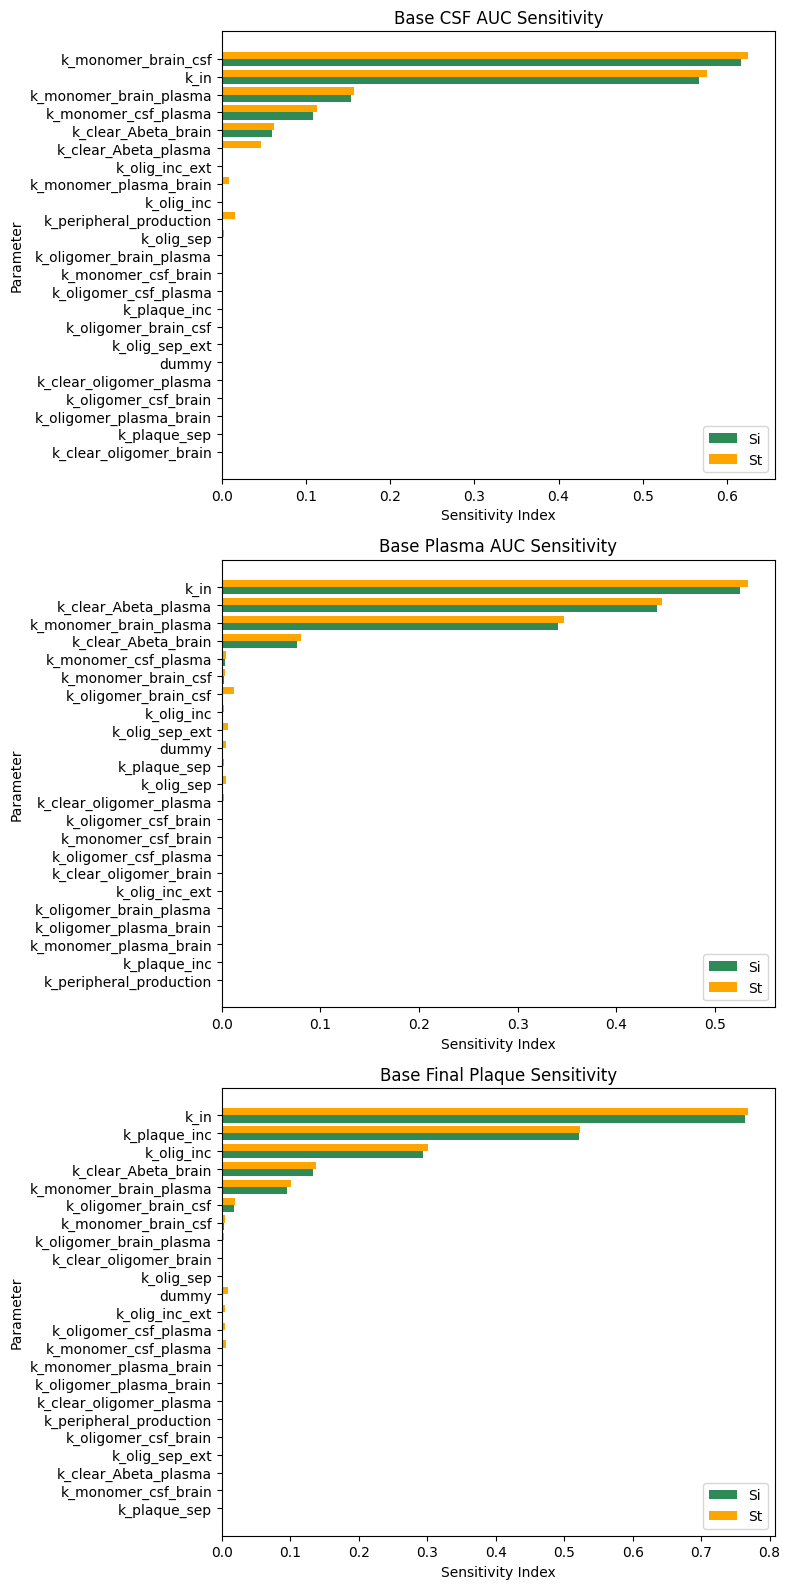

In [18]:
# Plot bar charts for each base sensitivity dataframe against parameter names

fig, axes = plt.subplots(3, 1, figsize=(8, 16), sharex=False)

base_sensitivity_dfs = [base_CSF_AUC, base_plasma_AUC, base_final_plaque]
base_St_sensitivity_dfs = [base_CSF_AUC_St, base_plasma_AUC_St, base_final_plaque_St]
titles = [
    "Base CSF AUC Sensitivity",
    "Base Plasma AUC Sensitivity",
    "Base Final Plaque Sensitivity"
]

for ax, df, St, title in zip(axes, base_sensitivity_dfs, base_St_sensitivity_dfs, titles):
    values = df.iloc[:,0]
    St_values = St.iloc[:,0]
    # Get the corresponding parameter names (handle length mismatch)
    params = params_list[:len(values)]
    # Sort values and params from highest to lowest
    sorted_indices = np.argsort(values.values)
    values = values.values[sorted_indices]
    St_values = St_values.values[sorted_indices]
    params_sorted = [params[i] for i in sorted_indices]
    y_pos = np.arange(len(params))

    ax.barh(y_pos - bar_width/2, values, height=bar_width, color='seagreen', label="Si")
    ax.barh(y_pos + bar_width/2, St_values, height=bar_width, color='orange',   label="St")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(params_sorted)
    ax.set_title(title)
    ax.set_xlabel("Sensitivity Index")
    ax.set_ylabel("Parameter")
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('Plots/base_model_sensitivities.png', dpi=300, bbox_inches='tight')


## Antibody PK sensitivities

Paired bar charts: Si (first-order) vs St (total-order) for mAb transport/clearance parameters.
Analysis run on the healthy base model (such that no antibody target/efficacy).

In [7]:
# --- Model with antibody: eFAST Si outputs ---
# CSF/plasma AUC ratio, brain/plasma AUC ratio, plasma antibody AUC
PK_CSF_ratio = pd.read_csv('Results/Si_CSF_ratio_PK.csv', header=None)
PK_brain_ratio = pd.read_csv('Results/Si_brain_ratio_PK.csv', header=None)
PK_plasma_AUC = pd.read_csv('Results/Si_plasma_PK.csv', header=None)

In [8]:
# Total-order sensitivities (St) for the same three outputs
St_CSF_ratio = pd.read_csv('Results/Sti_CSF_ratio.csv', header=None)
St_brain_ratio = pd.read_csv('Results/Sti_brain_ratio.csv', header=None)
St_plasma_AUC = pd.read_csv('Results/Sti_plasma_PK.csv', header=None)

In [9]:
# Parameter names in the same order as the Matlab eFAST export (last entry is dummy)
PK_params_list = ['k_mAb_plasma_brain', 'k_mAb_brain_plasma', 'k_mAb_csf_plasma', 'k_mAb_brain_csf',  'k_mAb_plasma_csf', 'k_mAb_csf_plasma', 'k_mAb_plasma_clear', 'dummy']

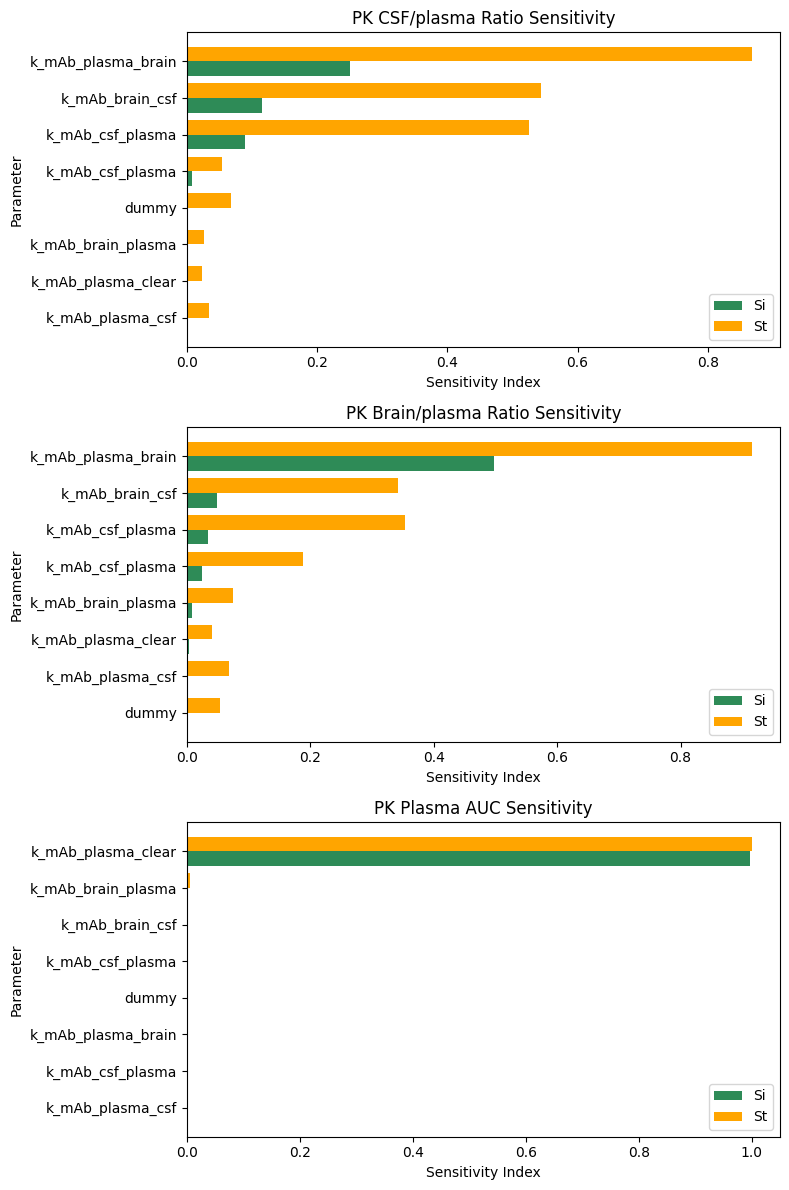

In [10]:
# Plot bar charts for each PK sensitivity dataframe, adding St (total sensitivity) as a paired bar for each parameter

St_sensitivity_dfs = [St_CSF_ratio, St_brain_ratio, St_plasma_AUC]
bar_width = 0.4

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=False)

PK_sensitivity_dfs = [PK_CSF_ratio, PK_brain_ratio, PK_plasma_AUC]
PK_titles = [
    "PK CSF/plasma Ratio Sensitivity",
    "PK Brain/plasma Ratio Sensitivity",
    "PK Plasma AUC Sensitivity"
]

for ax, Si_df, St_df, title in zip(axes, PK_sensitivity_dfs, St_sensitivity_dfs, PK_titles):
    si_values = Si_df.iloc[:, 0]
    st_values = St_df.iloc[:, 0]
    params = PK_params_list[:len(si_values)]
    sorted_indices = np.argsort(si_values.values)
    si_values = si_values.values[sorted_indices]
    st_values = st_values.values[sorted_indices]
    params_sorted = [params[i] for i in sorted_indices]
    y_pos = np.arange(len(params))
    
    ax.barh(y_pos - bar_width/2, si_values, height=bar_width, color='seagreen', label="Si")
    ax.barh(y_pos + bar_width/2, st_values, height=bar_width, color='orange',   label="St")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(params_sorted)
    ax.set_title(title)
    ax.set_xlabel("Sensitivity Index")
    ax.set_ylabel("Parameter")
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('Plots/PK_model_sensitivities.png', dpi=300, bbox_inches='tight')

## PD (plaque) sensitivities — early vs final time point

Includes clearance parameters `k_ADCP` and `scale` in addition to mAb PK rates.
Analysis run on the disease base model.

In [11]:
# --- Model with antibody: eFAST Si and St outputs ---
# plaque level at 3 months and at 18 months
early_PD = pd.read_csv('Results/Si_early_plaque_repeat.csv', header=None)
final_PD = pd.read_csv('Results/Si_final_plaque_repeat.csv', header=None)
early_PD_St = pd.read_csv('Results/Sti_early_plaque_repeat.csv', header=None)
final_PD_St = pd.read_csv('Results/Sti_final_plaque_repeat.csv', header=None)


In [12]:
# Parameter names in the same order as the Matlab eFAST export (last entry is dummy)
PD_params_list = ['k_mAb_plasma_brain', 'k_mAb_brain_plasma', 'k_mAb_csf_plasma', 'k_mAb_brain_csf',  'k_mAb_plasma_csf', 'k_mAb_csf_plasma', 'k_mAb_plasma_clear', 'k_ADCP', 'scale', 'dummy']

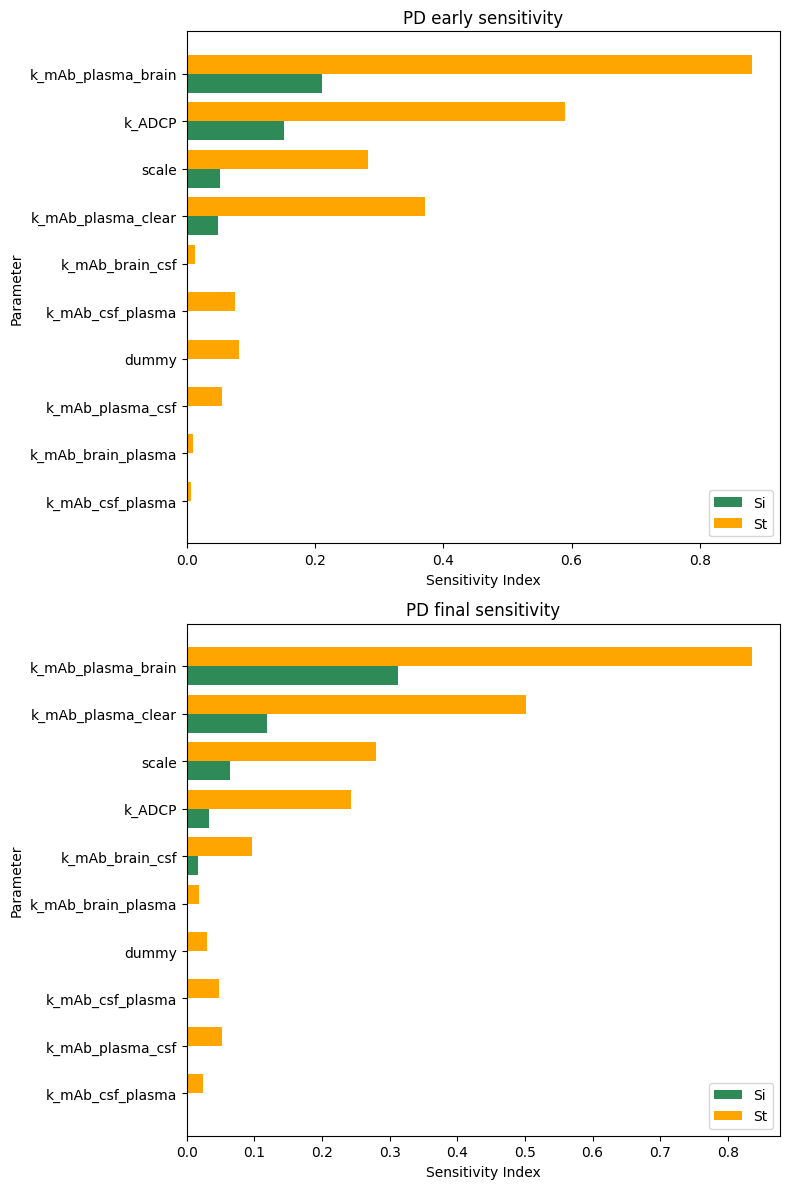

In [13]:
# Plot bar charts for each PD sensitivity dataframe, adding St (total sensitivity) as a paired bar for each parameter

PD_St_sensitivity_dfs = [early_PD_St, final_PD_St]
bar_width = 0.4

fig, axes = plt.subplots(2, 1, figsize=(8, 12), sharex=False)

PD_sensitivity_dfs = [early_PD, final_PD]
PD_titles = [
    "PD early sensitivity",
    "PD final sensitivity"
]

for ax, Si_df, St_df, title in zip(axes, PD_sensitivity_dfs, PD_St_sensitivity_dfs, PD_titles):
    si_values = Si_df.iloc[:, 0]
    st_values = St_df.iloc[:, 0]
    params = PD_params_list[:len(si_values)]

    sorted_indices = np.argsort(si_values.values)
    si_values = si_values.values[sorted_indices]
    st_values = st_values.values[sorted_indices]
    params_sorted = [params[i] for i in sorted_indices]
    y_pos = np.arange(len(params))
    
    ax.barh(y_pos - bar_width/2, si_values, height=bar_width, color='seagreen', label="Si")
    ax.barh(y_pos + bar_width/2, st_values, height=bar_width, color='orange',   label="St")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(params_sorted)
    ax.set_title(title)
    ax.set_xlabel("Sensitivity Index")
    ax.set_ylabel("Parameter")
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('Plots/PD_model_sensitivities.png', dpi=300, bbox_inches='tight')


## Profile likelihood (1D scans)

Fix one of (k_ADCP, scale) and scan the other.

In [14]:
# Error scores evaluated for simulations with 10 mg/kg Q2W lecanemab.
# Fitted scale values for each k_ADCP
ADCP_fix_scale_fit = pd.read_csv('Results/ADCP_fix_prolik_scale_fit_0_1.csv', header=None)
# Corresponding error scores
ADCP_fix_scale_fit_err = pd.read_csv('Results/ADCP_fix_prolik_err_0_1.csv', header=None)
# Fitted k_ADCP values for each scale
scale_fix_ADCP_fit = pd.read_csv('Results/scale_fix_prolik_ADCP_fit_0_1.csv', header=None)
# Corresponding error scores
scale_fix_ADCP_fit_err = pd.read_csv('Results/scale_fix_prolik_err_0_1.csv', header=None)

# Range of k_ADCP values to scan
ADCP_range = np.linspace(-5, -1, 20)
# Range of scale values to scan
scale_range = np.linspace(0, 25, 20)


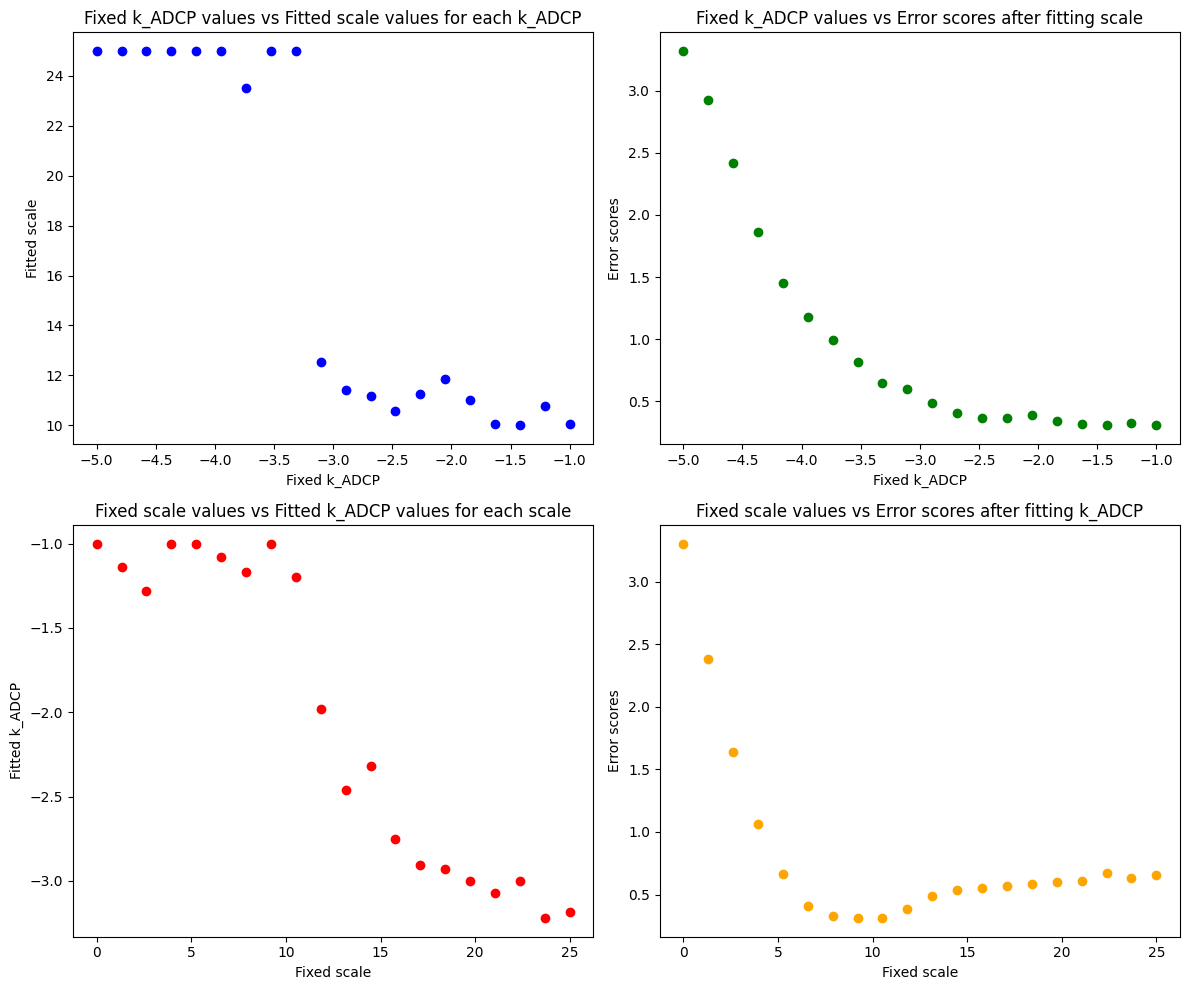

In [15]:
# Plot scatter plots of the fitted values and error scores for each parameter scan
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plot a) Fixed k_ADCP values vs Fitted scale values for each k_ADCP
axes[0, 0].scatter(ADCP_range, ADCP_fix_scale_fit.values.flatten(), color='b')
axes[0, 0].set_title('Fixed k_ADCP values vs Fitted scale values for each k_ADCP')
axes[0, 0].set_xlabel('Fixed k_ADCP')
axes[0, 0].set_ylabel('Fitted scale')

# Scatter plot b) Fixed k_ADCP values vs Error scores after fitting scale
axes[0, 1].scatter(ADCP_range, ADCP_fix_scale_fit_err.values.flatten(), color='g')
axes[0, 1].set_title('Fixed k_ADCP values vs Error scores after fitting scale')
axes[0, 1].set_xlabel('Fixed k_ADCP')
axes[0, 1].set_ylabel('Error scores')

# Scatter plot c) Fixed scale values vs Fitted k_ADCP values for each scale
axes[1, 0].scatter(scale_range, scale_fix_ADCP_fit.values.flatten(), color='r')
axes[1, 0].set_title('Fixed scale values vs Fitted k_ADCP values for each scale')
axes[1, 0].set_xlabel('Fixed scale')
axes[1, 0].set_ylabel('Fitted k_ADCP')

# Scatter plot d) Fixed scale values vs Error scores after fitting k_ADCP
axes[1, 1].scatter(scale_range, scale_fix_ADCP_fit_err.values.flatten(), color='orange')
axes[1, 1].set_title('Fixed scale values vs Error scores after fitting k_ADCP')
axes[1, 1].set_xlabel('Fixed scale')
axes[1, 1].set_ylabel('Error scores')

plt.tight_layout()
plt.show()

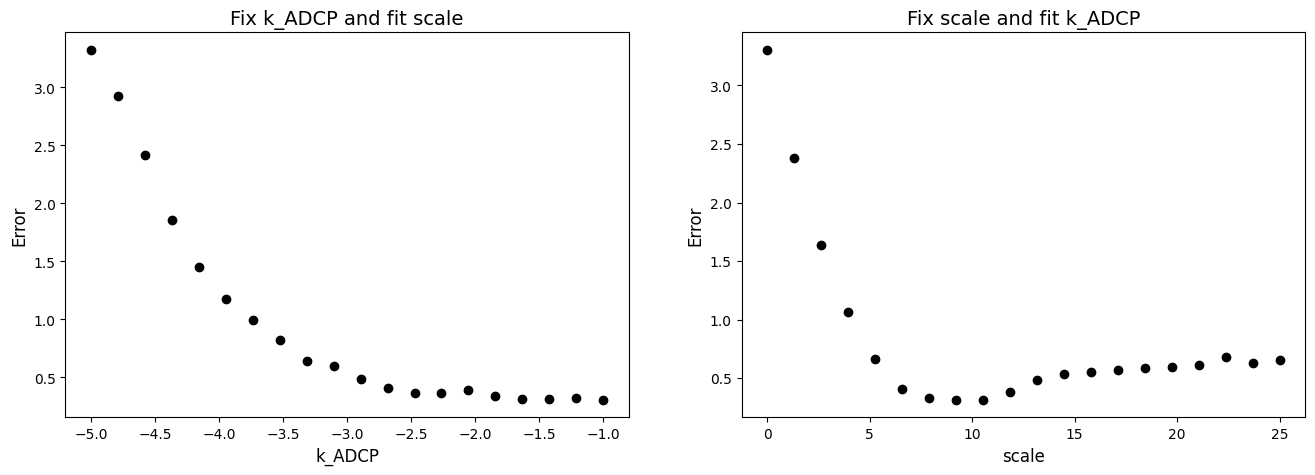

In [17]:
# Plot scatter plots of the error scores for each parameter scan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot b) ADCP range vs error score
axes[0].scatter(ADCP_range, ADCP_fix_scale_fit_err.values.flatten(), color='k')
axes[0].set_title('Fix k_ADCP and fit scale', fontsize=14)
axes[0].set_xlabel('k_ADCP', fontsize=12)
axes[0].set_ylabel('Error', fontsize=12)

# Scatter plot d) scale_range vs error score
axes[1].scatter(scale_range, scale_fix_ADCP_fit_err.values.flatten(), color='k')
axes[1].set_title('Fix scale and fit k_ADCP', fontsize=14)
axes[1].set_xlabel('scale', fontsize=12)
axes[1].set_ylabel('Error', fontsize=12)

plt.savefig('Plots/profile_likelihood.png', dpi=300, bbox_inches='tight')


In [19]:
# Find the scale which leads to the lowest error and the corresponding fitted k_ADCP value
min_error_idx = scale_fix_ADCP_fit_err.values.flatten().argmin()
best_scale = scale_range[min_error_idx]
best_k_ADCP = scale_fix_ADCP_fit.values.flatten()[min_error_idx]

print(f"Scale with lowest error: {best_scale}")
print(f"Corresponding fitted k_ADCP: {best_k_ADCP}")

Scale with lowest error: 10.526315789473685
Corresponding fitted k_ADCP: -1.1958
